## 7.3 梯度优化方法 - RMSProp（学习率）

#### 1. 为什么需要 RMSProp
在上一节 AdaGrad 中，我们学习了自适应学习率方法。

AdaGrad 的核心公式：

![St = St-1 + 9t.png](<attachment:St = St-1 + 9t.png>)

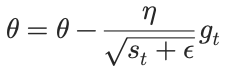

AdaGrad 的优点是：
* 可以为每个参数自动调整学习率

但是它存在一个严重问题：
* s_t 会不断累加

因此：
* √s_t 会越来越大

最终导致：
* 学习率越来越小

训练会变得：
* 几乎停止更新
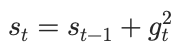

#### 2. RMSProp 的核心思想
RMSProp（Root Mean Square Propagation）提出：

`不要累加所有历史梯度，而是使用指数移动平均（EMA）。`

也就是说：
* 通过EMA的衰减系数
* 历史梯度权重指数衰减

而不是：
* 累加所有历史梯度

这样就可以避免：
* 学习率不断减小

#### 3. RMSProp 的数学公式
RMSProp 用 EMA（指数移动平均） 替代 AdaGrad 的累加。

##### 3.1 计算梯度平方的 EMA

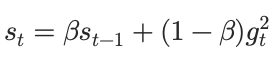

其中：

![Pasted Graphic 5.png](<attachment:Pasted Graphic 5.png>)
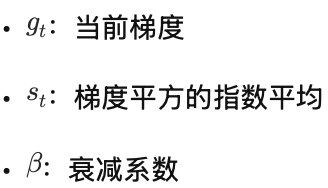

##### 3.2 参数更新

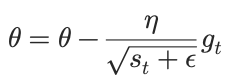

其中：

![Pasted Graphic 7.png](<attachment:Pasted Graphic 7.png>)
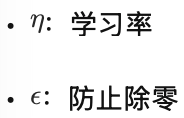

##### ⚠️注意：
```
这里的每一次的梯度表示同一层的各个参数的梯度在每一个次 batch 训练之后的梯度
而不是表示同一个 batch 中的每一层的各个参数的梯度
```
1. 每一个 batch 会计算一次梯度
2. 这个梯度包含 所有参数的梯度
3. Momentum 会 对每一个参数的梯度序列做 EMA

这里的：
`g_t`

其实是：

`当前 batch 的梯度`

所以：
```
g1 = 第1个batch得到的梯度
g2 = 第2个batch得到的梯度
g3 = 第3个batch得到的梯度
```

#### 4. RMSProp 的直观理解
RMSProp 可以理解为：
* 对梯度平方做 EMA

也就是说：
* 通过EMA的衰减系数
* 历史梯度权重指数衰减

如果：
* 最近梯度很大

则：
* 学习率变小

如果：
* 最近梯度很小

则：
* 学习率变大

因此 RMSProp 实现了：

`动态学习率调整`

#### 5. RMSProp 与 AdaGrad 的区别
我们可以直接对比两种算法。

##### 5.1 AdaGrad

![St = St-1 + 9t.png](<attachment:St = St-1 + 9t.png>)

特点：
* 不断累加所有历史梯度
* 所有历史梯度权重相同

`g1² + g2² + g3² + g4²`

可以看到：
* 所有历史梯度的权重 = 1

结果：
* s_t 会一直变大
* 学习率不断下降
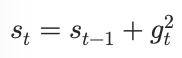

##### 5.2 RMSProp

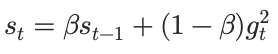

特点：
* 综合所有的历史梯度
* 历史梯度权重指数衰减

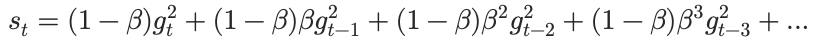

可以看到：
* 越旧的梯度权重越小
* 很久以前的梯度：几乎可以忽略

结果：
* 梯度受到最近的梯度影响较大，早期梯度影响较小
* 学习率不会无限下降

#### 6. RMSProp 与 Momentum 的关系
我们之前学习：
* Momentum

Momentum 使用：
* EMA(梯度)
* 直接作用于梯度本身

RMSProp 使用：
* EMA(梯度平方)
* 作用于学习率
```
方法	EMA对象
Momentum	梯度
RMSProp	梯度平方
```

#### 7. RMSProp 的优点
RMSProp 相比 AdaGrad 有明显优势。

**1️⃣ 学习率不会无限减小**

因为：
* 使用 EMA

所以：
* 历史梯度会逐渐衰减

**2️⃣ 训练更加稳定**

RMSProp 可以：
* 平衡不同参数的更新速度

避免：
* 某些参数更新过大

**3️⃣ 适合深度神经网络**

RMSProp 在训练：
* RNN
* CNN
* 深度网络

时表现良好。

#### 8. RMSProp 的缺点
RMSProp 仍然只解决了：
* 学习率问题

但没有解决：
* 梯度大小和方向问题

因此后来提出：

`Adam`

Adam 同时使用：

`Momentum（用于梯度） + RMSProp（用于学习率）`

即：
```
EMA(梯度) 用于梯度
+
EMA(梯度平方) 用于学习率
```
成为目前深度学习中 最常用的优化算法。

#### 9. RMSProp 在 Pytorch 中的实现
在 Pytorch 中，RMSProp 使用：

`torch.optim.RMSprop`

##### 9.1 基本写法

In [ ]:
import torch 

model = torch.nn.Linear(1, 1)

optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=0.001,
    alpha=0.9
)

##### 9.2 常见参数

In [ ]:
optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=0.001,
    alpha=0.9,
    eps=1e-8,
    weight_decay=0,
    momentum=0
)

##### 9.3 参数说明
* lr
    * 学习率
* alpha=0.9
    * 梯度平方 EMA 的衰减系数，对应公式中的 \beta
* eps
    * 防止除零的小常数
* weight_decay
    * L2 正则化
* momentum
    * RMSProp 中额外可选的动量参数